# SIADS 696 - Milestone II

## Supervised Learning

### Import the required modules


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import shap

pd.set_option('display.float_format', lambda x: '%.3f' % x)

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from sklearn.linear_model import  Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, 
)
from sklearn.inspection import permutation_importance
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import (
    GridSearchCV, HalvingGridSearchCV, RandomizedSearchCV,
    cross_val_score, KFold, learning_curve
)



### Import Train/Test Data from Pipeline


In [2]:
# Import the data
BIN = Path('bin')
X_train = pd.read_csv(BIN / 'X_train.csv')
y_train = pd.read_csv(BIN / 'y_train.csv')
X_test  = pd.read_csv(BIN / 'X_test.csv')
y_test  = pd.read_csv(BIN / 'y_test.csv')


# Use a subset of the data when building and testing models
USE_SUBSET   = False        
SUBSET_FRAC  = 0.05        
SEED         = 42

if USE_SUBSET:
    def _sub(df): return df.sample(frac=SUBSET_FRAC, random_state=SEED).reset_index(drop=True)
    X_train, y_train = _sub(X_train), _sub(y_train)
    X_test , y_test  = _sub(X_test) , _sub(y_test)

print(f"{X_train.shape[0]:,} train rows  |  {X_test.shape[0]:,} test rows")


# Set and flatten targert variable
target_variable = 'Beta_winsorized'
y_train = y_train[target_variable].values.ravel()
y_test  = y_test[target_variable].values.ravel()

print(pd.Series(y_train, name=target_variable).head())

40,433 train rows  |  10,109 test rows
0   1.009
1   1.774
2   1.438
3   1.248
4   0.988
Name: Beta_winsorized, dtype: float64


### Import the metadata 

In [3]:
# Variable labels (short human-readable descriptions)
with open('variable_labels.yaml') as f:
    variable_labels_dict = yaml.safe_load(f)

# SAS format for each original variable (tells you if cat / numeric)
with open('variable_formats.yaml') as f:
    variable_formats_dict = yaml.safe_load(f)

# Mapping from format-name → {category-code: category-text}
with open('categorical_variables_categories.yaml') as f:
    categorical_variables_categories_dict = yaml.safe_load(f)

# List of all one-hot (dummy) columns produced during cleaning
with open('cleaned_variables.yaml') as f:
    cleaned_vars = yaml.safe_load(f)
new_categorical_variables = set(cleaned_vars['categorical_variables'])

## Model Creation

### Function to tune and evaluate models

In [4]:
def tune_and_evaluate(model_cls, param_grid, *,
                      X_train, y_train, X_test, y_test,
                      label='', search_strategy='grid',
                      cv_splits=5, random_state=42, n_iter=10, factor=3,
                      metric='neg_root_mean_squared_error'):


        cv = KFold(n_splits=cv_splits, shuffle=True, random_state=random_state)

        if issubclass(model_cls, KNeighborsRegressor):
            base = Pipeline([('scale', StandardScaler()),
                            ('knn', model_cls())])
            param_grid = {('knn__' + k if not k.startswith('knn__') else k): v
                        for k, v in param_grid.items()}
        else:
            kwargs = {'random_state': random_state} if 'random_state' in model_cls().get_params() else {}
            base = model_cls(**kwargs)

        strategy_map = {
            'grid'   : (GridSearchCV,       {'param_grid': param_grid}),
            'random' : (RandomizedSearchCV, {'param_distributions': param_grid,
                                            'n_iter': n_iter, 'random_state': random_state})
        }
        SearchCV, extra_kw = strategy_map[search_strategy]
        search = SearchCV(estimator=base, scoring=metric, cv=cv,
                        n_jobs=-1, verbose=0, **extra_kw).fit(X_train, y_train)

        best = search.best_estimator_
        y_pred = best.predict(X_test)
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        cv_mean = -search.cv_results_['mean_test_score'][search.best_index_]
        cv_std  =  search.cv_results_['std_test_score'][search.best_index_]

        return best, {'model': f'{label or model_cls.__name__} (tuned – {search_strategy})',
                    'MAE': mae,
                    'RMSE': rmse,
                    'CV_RMSE_mean': cv_mean,
                    'CV_RMSE_sd': cv_std,
                    'best_params': search.best_params_}

### Set the Hyper-parameter grids

In [5]:
gb_grid   = {'learning_rate':[.02,.03,.04], 'max_depth':[10,15,20],
             'max_iter':[500,1000,1500], 'l2_regularization':[0,.0005,.001],
             'min_samples_leaf':[10,20], 'max_leaf_nodes':[31,63]}

lasso_grid= {'alpha':np.logspace(-4,-1,7), 'max_iter':[5000]}

def _max_k():
    return min(15, max(3, (len(X_train) // 5) - 1))

knn_grid  = {'n_neighbors': list(range(3, _max_k()+1, 2)),
             'weights':['uniform','distance'], 'p':[1,2]}

## Train the Models

###  Find the best model type using a fast Randomized Search 

In [6]:
model_configs = [
    {'label': 'GB',    'class': HistGradientBoostingRegressor, 'grid': gb_grid},
    {'label': 'Lasso', 'class': Lasso,                         'grid': lasso_grid},
    {'label': 'k-NN',  'class': KNeighborsRegressor,           'grid': knn_grid}
]

results_random = []
best_models = {} 

for config in model_configs:
    best, res = tune_and_evaluate(
        config['class'], config['grid'],
        X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
        label=config['label'], search_strategy='random'
    )
    res.update(config)
    results_random.append(res)
    best_models[config['label']] = best 
    print(f"Finished random search for {res['model']}")

print("\n--- Randomized Search Results ---")
results_df_random = (pd.DataFrame(results_random)
                       .sort_values('CV_RMSE_mean'))

display(results_df_random[['model', 'MAE', 'RMSE', 'CV_RMSE_mean', 'CV_RMSE_sd']]
        .style.format({'MAE':'{:.4f}', 'RMSE':'{:.4f}',
                       'CV_RMSE_mean':'{:.4f}', 'CV_RMSE_sd':'{:.4f}'}))

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Finished random search for GB (tuned – random)


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 7 is smaller than n_iter=10. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Finished random search for Lasso (tuned – random)


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Finished random search for k-NN (tuned – random)

--- Randomized Search Results ---


,model,MAE,RMSE,CV_RMSE_mean,CV_RMSE_sd
0,GB (tuned – random),0.4000,0.5881,0.5831,0.0030
1,Lasso (tuned – random),0.4323,0.6288,0.6219,0.0031
2,k-NN (tuned – random),0.4642,0.6627,0.6578,0.0047


### Fine-tune the best model using an exhaustive Grid Search 


In [7]:
best_model_config = results_df_random.iloc[0]
print(f"\n--- Stage 2: Fine-tuning '{best_model_config['label']}' with GridSearchCV ---")
print("This stage performs an exhaustive search on the best model type to find optimal hyperparameters.")

best_model_final, final_results = tune_and_evaluate(
    best_model_config['class'], best_model_config['grid'],
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
    label=best_model_config['label'], search_strategy='grid'
)
print("\nBest Hyperparameters:")
print(final_results['best_params'])


--- Stage 2: Fine-tuning 'GB' with GridSearchCV ---
This stage performs an exhaustive search on the best model type to find optimal hyperparameters.


/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Hyperparameters:
{'l2_regularization': 0.0005, 'learning_rate': 0.03, 'max_depth': 15, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 10}


In [8]:
final_model_label = f"{best_model_config['label']} (Grid)"
best_models[final_model_label] = best_model_final

print("\n--- Final Tuned Model Results (Grid Search) ---")
final_results_df = pd.DataFrame([final_results]).set_index('model')
display(final_results_df.style.format({'MAE':'{:.4f}', 'RMSE':'{:.4f}',
                                      'CV_RMSE_mean':'{:.4f}', 'CV_RMSE_sd':'{:.4f}'}))

print("\nBest Hyperparameters:")
print(final_results['best_params'])


--- Final Tuned Model Results (Grid Search) ---


,MAE,RMSE,CV_RMSE_mean,CV_RMSE_sd,best_params
model,,,,,
GB (tuned – grid),0.3994,0.5871,0.5826,0.0028,"{'l2_regularization': 0.0005, 'learning_rate': 0.03, 'max_depth': 15, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 10}"



Best Hyperparameters:
{'l2_regularization': 0.0005, 'learning_rate': 0.03, 'max_depth': 15, 'max_iter': 500, 'max_leaf_nodes': 63, 'min_samples_leaf': 10}


In [9]:
if 'model' not in final_results_df.columns:
    final_results_df = final_results_df.rename_axis('model').reset_index()

results_df_random  = results_df_random.reset_index(drop=True)

model_comparison = (
    pd.concat([results_df_random, final_results_df], ignore_index=True)
      .sort_values('CV_RMSE_mean')
      [['model','MAE','RMSE','CV_RMSE_mean','CV_RMSE_sd']]
)

num_cols = ['MAE', 'RMSE', 'CV_RMSE_mean', 'CV_RMSE_sd']
display(
    model_comparison
        .style
        .hide(axis="index")                     # suppress row numbers
        .format({c: '{:.4f}' for c in num_cols})
)


model,MAE,RMSE,CV_RMSE_mean,CV_RMSE_sd
GB (tuned – grid),0.3994,0.5871,0.5826,0.0028
GB (tuned – random),0.4000,0.5881,0.5831,0.0030
Lasso (tuned – random),0.4323,0.6288,0.6219,0.0031
k-NN (tuned – random),0.4642,0.6627,0.6578,0.0047


### Learning Curve

/Users/pdsmbp/miniconda3/envs/mads_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


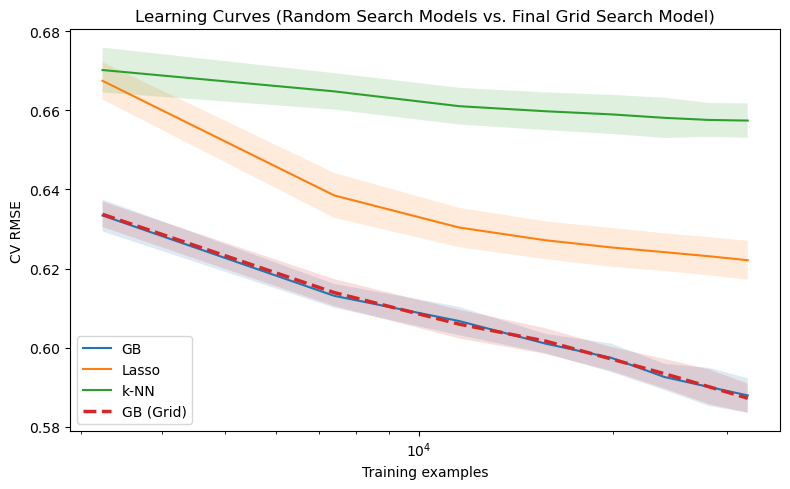

In [10]:
def safe_learning_curve(model, X, y, cv_splits=5, train_sizes=np.linspace(0.1, 1.0, 8)):

    # Ensure cv splits is valid for the data size
    cv = min(cv_splits, max(2, len(y) // 2))

    # A safeguard for k-NN: n_neighbors cannot be >= n_samples in a CV split.
    # This temporarily reduces k for the learning curve calculation if needed.
    if isinstance(model, Pipeline) and 'knn' in dict(model.named_steps):
        k = model.named_steps['knn'].n_neighbors
        # Check against the smallest training set size
        if k >= len(y) * train_sizes[0]:
            model = clone(model)
            model.named_steps['knn'].n_neighbors = int(len(y) * train_sizes[0]) - 1

    s, train_scores, val_scores = learning_curve(model, X, y,
                                                 cv=cv,
                                                 train_sizes=train_sizes,
                                                 scoring='neg_root_mean_squared_error',
                                                 n_jobs=-1)
    # Return sizes, and the mean and std of the validation scores
    return s, -val_scores.mean(axis=1), val_scores.std(axis=1)

# Generate learning curves for all models stored in the `best_models` dictionary
curves = {}
for name, mdl in best_models.items():
    s, m, sd = safe_learning_curve(mdl, X_train, y_train)
    curves[name] = (s, m, sd)


# Plot the learning curves for comparison
plt.figure(figsize=(8, 5))
for name, (s, m, sd) in curves.items():
    # Highlight the final, grid-searched model with a different style
    style = {'linewidth': 2.5, 'linestyle': '--'} if '(Grid)' in name else {}
    plt.plot(s, m, label=name, **style)
    plt.fill_between(s, m - sd, m + sd, alpha=0.15)

plt.xscale('log')
plt.xlabel('Training examples')
plt.ylabel('CV RMSE')
plt.title('Learning Curves (Random Search Models vs. Final Grid Search Model)')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of Most Performant  Model

### Feature Importance and Ablation

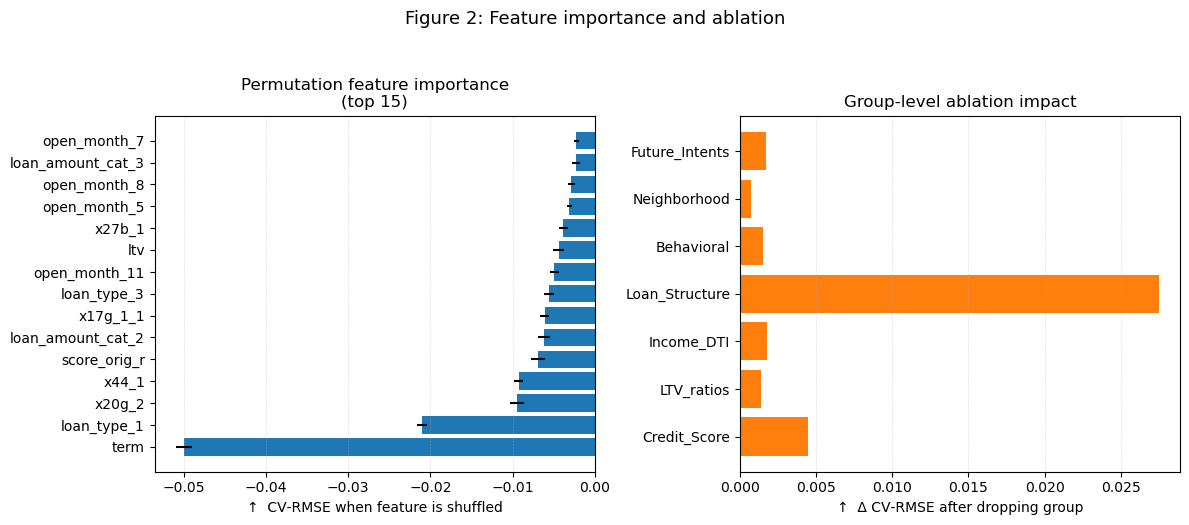

In [11]:
perm = permutation_importance(
    best_model_final, X_test, y_test,
    n_repeats=10, random_state=42,
    scoring='neg_root_mean_squared_error'
)
# Get top‑15 features
idx_sorted = perm.importances_mean.argsort()[::-1][:15]
top_feats  = X_test.columns[idx_sorted]
imp_mean   = perm.importances_mean[idx_sorted] * -1  
imp_sd     = perm.importances_std[idx_sorted]


# Define the featured groups 
groups = {
    "Credit_Score":  [c for c in X_train.columns
                      if any(k in c.lower() for k in ("credit", "score", "fico", "vantage"))],

    "LTV_ratios":    [c for c in X_train.columns
                      if c.lower().startswith(("ltv", "cltv"))],

    "Income_DTI":    [c for c in X_train.columns
                      if any(k in c.lower() for k in ("dti", "income"))],


    "Loan_Structure":  [c for c in X_train.columns
                        if c.split("_")[0] in {"term", "rate_spread", "pmms", 
                                              "loan_type", "jumbo", "x44", "x46e", "x54"}],

    "Behavioral":      [c for c in X_train.columns
                        if c.split("_")[0] in {"x05a","x05b","x05c","x05d","x05e","x05f",
                                               "x56a","x56b","x56c","x56d","x56e","x08"}],
                                                   
    "Neighborhood":    [c for c in X_train.columns
                        if c.split("_")[0] in {"x68a","x68b","x68c","x68d","x68e","x68f",
                                               "x69","x70","mtmltv"}],

    "Future_Intents":  [c for c in X_train.columns
                        if c.split("_")[0] in {"x71a","x71b","x71c","x6701"}],
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
base_rmse = -cross_val_score(best_model_final, X_train, y_train,
                             scoring='neg_root_mean_squared_error',
                             cv=cv, n_jobs=-1).mean()

abl_names, abl_delta = [], []
for name, cols in groups.items():
    X_drop = X_train.drop(columns=cols)
    rmse = -cross_val_score(best_model_final
    , X_drop, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=cv, n_jobs=-1).mean()
    abl_names.append(name)
    abl_delta.append(rmse - base_rmse)   

# Save the permutation importance to csv
pd.Series(perm.importances_mean, index=X_test.columns)\
  .sort_values(ascending=False)\
  .to_csv("full_permutation_importance.csv")

# Plot the Feature Importance and Ablation Impact
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Permutation importance Plot
axes[0].barh(range(len(top_feats))[::-1], imp_mean,
             xerr=imp_sd, align='center')
axes[0].set_yticks(range(len(top_feats))[::-1])
axes[0].set_yticklabels(top_feats)
axes[0].set_xlabel('↑  CV‑RMSE when feature is shuffled')
axes[0].set_title('Permutation feature importance\n(top 15)')

# Group Ablation Impact Plot
axes[1].barh(range(len(abl_names))[::-1], abl_delta, color='tab:orange')
axes[1].set_yticks(range(len(abl_names))[::-1])
axes[1].set_yticklabels(abl_names)
axes[1].set_xlabel('↑  Δ CV‑RMSE after dropping group')
axes[1].set_title('Group‑level ablation impact')

for ax in axes: ax.invert_yaxis(); ax.grid(axis='x', ls='--', lw=.4, alpha=.5)
fig.suptitle('Figure 2: Feature importance and ablation', y=1.04, fontsize=13)
plt.tight_layout()

### Sensitivity Analysis (Learning Rate)

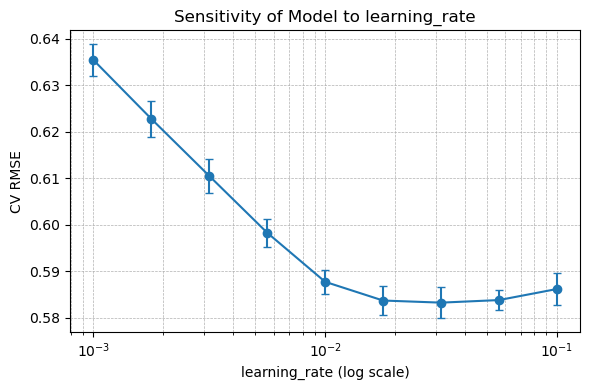

In [12]:
lr_vals = np.logspace(-3, -1, 9)    
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mean_rmse, sd_rmse = [], []
for lr in lr_vals:
    mod = best_model_final.set_params(learning_rate=lr)
    
    scores = cross_val_score(mod, X_train, y_train,
                             scoring='neg_root_mean_squared_error',
                             cv=cv, n_jobs=-1)
    mean_rmse.append(-scores.mean())
    sd_rmse.append(scores.std())

# Sensitivity Analysis Plot
plt.figure(figsize=(6,4))
plt.errorbar(lr_vals, mean_rmse, yerr=sd_rmse, marker='o', capsize=3)
plt.xscale('log')
plt.xlabel('learning_rate (log scale)')
plt.ylabel('CV RMSE')
plt.title('Sensitivity of Model to learning_rate')
plt.grid(True, which='both', ls='--', lw=.5)
plt.tight_layout()

### Failure Analysis


=== Failure #0 (Model bias on in-range record) ===


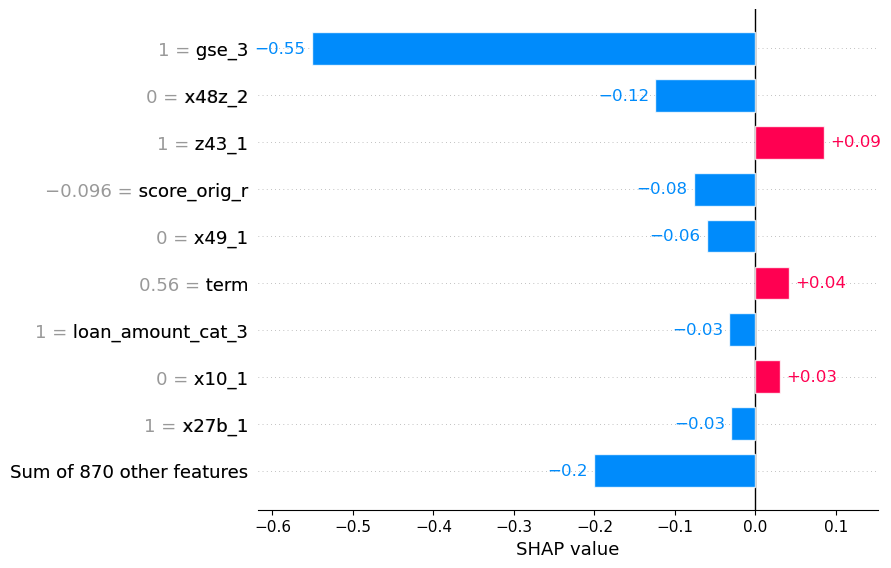


=== Failure #1 (Outlier / extrapolation) ===


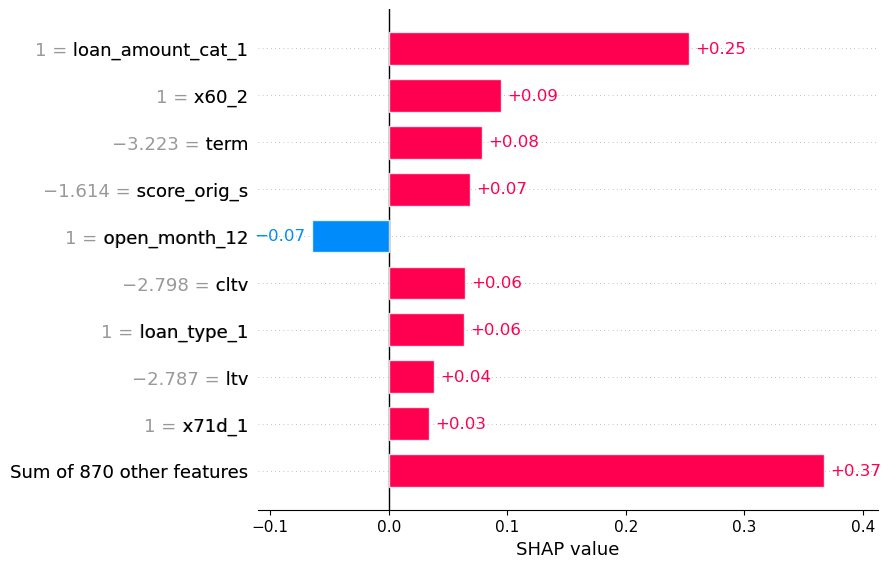


=== Failure #2 (Outlier / extrapolation) ===


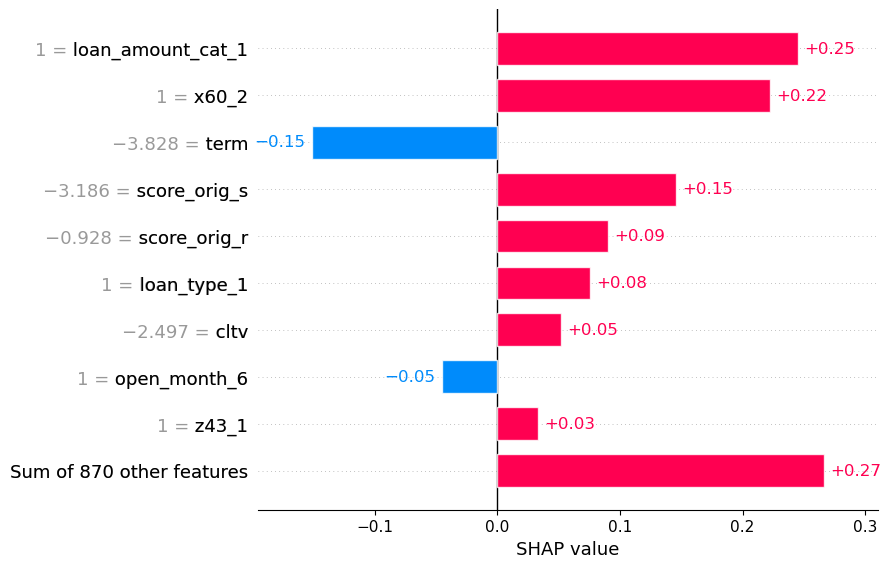

In [13]:
y_pred  = best_model_final.predict(X_test)
abs_err = np.abs(y_pred - y_test)
worst_idx = abs_err.argsort()[-3:][::-1]        
failure_df = (X_test.iloc[worst_idx]
              .assign(TrueVal = y_test[worst_idx],
                      Pred     = y_pred[worst_idx],
                      AbsErr   = abs_err[worst_idx])
              .reset_index(drop=True))


def classify_failure(row, z_thresh=2.5):
    num_cols = X_train.select_dtypes(include='number').columns
    if (row[num_cols].abs() > z_thresh).any():
        return 'Outlier / extrapolation'
    if row.get('cashout_1') and row.get('cashout_2'):
        return 'Conflicting categorical flags'
    return 'Model bias on in-range record'

failure_df['Category'] = failure_df.apply(classify_failure, axis=1)


explainer = shap.Explainer(best_model_final)
shap_vals = explainer(failure_df.drop(['TrueVal','Pred','AbsErr','Category'], axis=1))
for i in range(3):
    print(f"\n=== Failure #{i} ({failure_df.loc[i,'Category']}) ===")
    shap.plots.bar(shap_vals[i], max_display=10) 